<a href="https://colab.research.google.com/github/AmanDhole147/AmanDhole147/blob/main/practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# Name: Aman S Dhole
# PRN: 2141351246051
# Branch: IT
# Semester/Year: 7th/4th
# Practical No: 1

import numpy as np

class MCPNeuron:
    def __init__(self, weights, bias):
        self.weights = np.array(weights)
        self.bias = bias

    def step_function(self, x):
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        weighted_sum = np.dot(self.weights, inputs) + self.bias
        return self.step_function(weighted_sum)

# Define weights and bias for AND gate
# For AND gate, weights = [1, 1] and bias = -1.5
weights = [1, 1]
bias = -1.5

# Create MCPNeuron instance
and_gate = MCPNeuron(weights, bias)

# Test the AND gate
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
outputs = [and_gate.predict(np.array(x)) for x in inputs]

# Print the results
for (x, output) in zip(inputs, outputs):
    print(f"Input: {x} -> Output: {output}")


Input: (0, 0) -> Output: 0
Input: (0, 1) -> Output: 0
Input: (1, 0) -> Output: 0
Input: (1, 1) -> Output: 1


In [24]:
# Name: Aman S Dhole
# PRN: 2141351246051
# Branch: IT
# Semester/Year: 7th/4th
# Practical No: 1a
import numpy as np

class MCPNeuron:
    def __init__(self, weights, bias):
        self.weights = np.array(weights)
        self.bias = bias

    def step_function(self, x):
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        weighted_sum = np.dot(self.weights, inputs) + self.bias
        return self.step_function(weighted_sum)

# Define weights and bias for OR gate
# For OR gate, weights = [1, 1] and bias = -0.5
# This means if at least one input is 1, the weighted sum will be >= 0
# If both inputs are 0, the weighted sum will be -0.5, which is < 0.
weights = [1, 1]
bias = -0.5

# Create MCPNeuron instance for OR gate
or_gate = MCPNeuron(weights, bias)

# Test the OR gate
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
outputs = [or_gate.predict(np.array(x)) for x in inputs]

# Print the results
for (x, output) in zip(inputs, outputs):
    print(f"Input: {x} -> Output: {output}")


Input: (0, 0) -> Output: 0
Input: (0, 1) -> Output: 1
Input: (1, 0) -> Output: 1
Input: (1, 1) -> Output: 1


Epoch 0: Loss 44.592324139264086
Epoch 100: Loss 1.0876474357891497
Epoch 200: Loss 1.0374673135204915
Epoch 300: Loss 1.0160660675377338
Epoch 400: Loss 1.0048369761538682
Epoch 500: Loss 0.998944586894263
Epoch 600: Loss 0.9958525956226322
Epoch 700: Loss 0.9942300941885303
Epoch 800: Loss 0.993378697573082
Epoch 900: Loss 0.9929319329776483


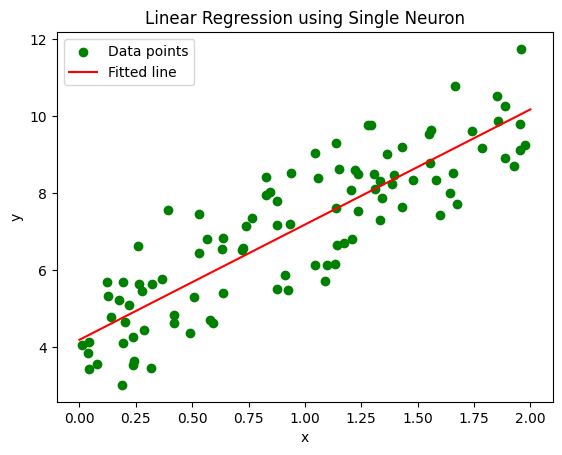

In [25]:
# Name: Aman S Dhole
# PRN: 2141351246051
# Branch: IT
# Semester/Year: 7th/4th
# Practical No: 2
import numpy as np
import matplotlib.pyplot as plt

class LinearNeuron:
    def __init__(self):
        self.weight = np.random.rand()
        self.bias = np.random.rand()

    def predict(self, x):
        return self.weight * x + self.bias

    def compute_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, x, y, learning_rate=0.01, epochs=1000):
        for i in range(epochs):
            # Predict
            y_pred = self.predict(x)

            # Compute loss
            loss = self.compute_loss(y, y_pred)

            # Compute gradients
            weight_gradient = -2 * np.mean((y - y_pred) * x)
            bias_gradient = -2 * np.mean(y - y_pred)

            # Update weights and bias
            self.weight -= learning_rate * weight_gradient
            self.bias -= learning_rate * bias_gradient

            if i % 100 == 0:  # Print loss every 100 epochs
                print(f'Epoch {i}: Loss {loss}')

# Generate some example data
np.random.seed(0)
x = 2 * np.random.rand(100)
y = 4 + 3 * x + np.random.randn(100)

# Create and train the linear neuron
neuron = LinearNeuron()
neuron.fit(x, y)

# Make predictions
x_test = np.linspace(0, 2, 100)
y_pred = neuron.predict(x_test)

# Plot the results
plt.scatter(x, y, color='green', label='Data points')
plt.plot(x_test, y_pred, color='red', label='Fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression using Single Neuron')
plt.show()


In [18]:
# Name: Aman S Dhole
# PRN: 2141351246051
# Branch: IT
# Semester/Year: 7th/4th
# Practical No: 3
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, z):
        return self.sigmoid(z) * (1 - self.sigmoid(z))

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-10)) / m

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, y_true, learning_rate=0.01):
        m = X.shape[0]

        # Compute gradients
        dZ2 = self.A2 - y_true
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.sigmoid_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights and biases
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def fit(self, X, y, epochs=1000, learning_rate=0.01):
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Compute loss
            loss = self.cross_entropy_loss(y, y_pred)

            # Backward pass
            self.backward(X, y, learning_rate)

            if epoch % 100 == 0:
                print(f'Epoch {epoch}: Loss {loss}')

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

# Generate synthetic data (e.g., XOR problem)
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)

# One-hot encode the target
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train MLP
input_size = X_train.shape[1]
hidden_size = 10
output_size = y_train.shape[1]

mlp = MLP(input_size, hidden_size, output_size)
mlp.fit(X_train, y_train, epochs=1000, learning_rate=0.01)

# Test the model
y_pred = mlp.predict(X_test)
y_true = np.argmax(y_test, axis=1)

# Calculate accuracy
accuracy = np.mean(y_pred == y_true)
print(f'Test accuracy: {accuracy * 100:.2f}%')


Epoch 0: Loss 0.671450460484224
Epoch 100: Loss 0.5324070628951142
Epoch 200: Loss 0.4610160283276161
Epoch 300: Loss 0.4171538207383921
Epoch 400: Loss 0.3888429373709462
Epoch 500: Loss 0.36974660458805175
Epoch 600: Loss 0.3563201252651657
Epoch 700: Loss 0.3465148564026405
Epoch 800: Loss 0.33910429252622476
Epoch 900: Loss 0.33332842802787793
Test accuracy: 84.50%


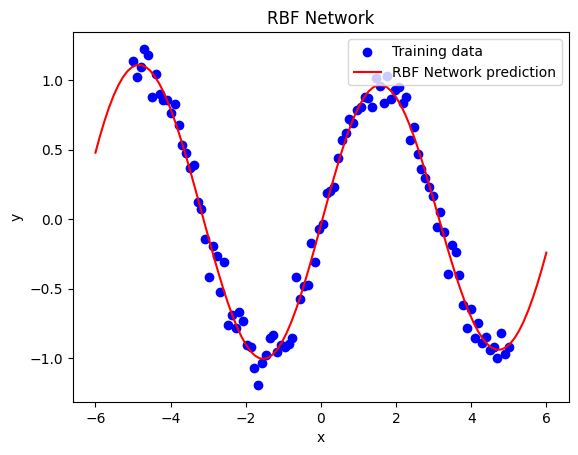

Mean Squared Error: 0.0046


In [16]:
# Name: Aman S Dhole
# PRN: 2141351246051
# Branch: IT
# Semester/Year: 7th/4th
# Practical No: 4
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

class RBFNetwork:
    def __init__(self, n_centers):
        self.n_centers = n_centers

    def _rbf(self, X, centers, sigma):
        # Compute the RBF activation
        return np.exp(-np.linalg.norm(X[:, np.newaxis] - centers, axis=2)**2 / (2 * sigma**2))

    def fit(self, X, y, sigma=1.0):
        # Standardize features
        self.scaler = StandardScaler()
        X = self.scaler.fit_transform(X)

        # Cluster centers using K-means
        kmeans = KMeans(n_clusters=self.n_centers, random_state=0).fit(X)
        self.centers = kmeans.cluster_centers_

        # Compute RBF activations
        Phi = self._rbf(X, self.centers, sigma)

        # Compute output weights using linear regression
        self.weights = np.linalg.pinv(Phi).dot(y)

    def predict(self, X):
        # Standardize features
        X = self.scaler.transform(X)

        # Compute RBF activations
        Phi = self._rbf(X, self.centers, sigma=1.0)

        # Predict output
        return Phi.dot(self.weights)

# Generate synthetic data (e.g., a simple function approximation)
np.random.seed(0)
X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Train RBF network
rbf = RBFNetwork(n_centers=10)
rbf.fit(X, y, sigma=1.0)

# Test the RBF network
X_test = np.linspace(-6, 6, 100).reshape(-1, 1)
y_pred = rbf.predict(X_test)

# Plot the results
plt.scatter(X, y, color='blue', label='Training data')
plt.plot(X_test, y_pred, color='red', label='RBF Network prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('RBF Network')
plt.show()

# Calculate and print error
y_true = np.sin(X_test).ravel()
mse = mean_squared_error(y_true, y_pred)
print(f'Mean Squared Error: {mse:.4f}')


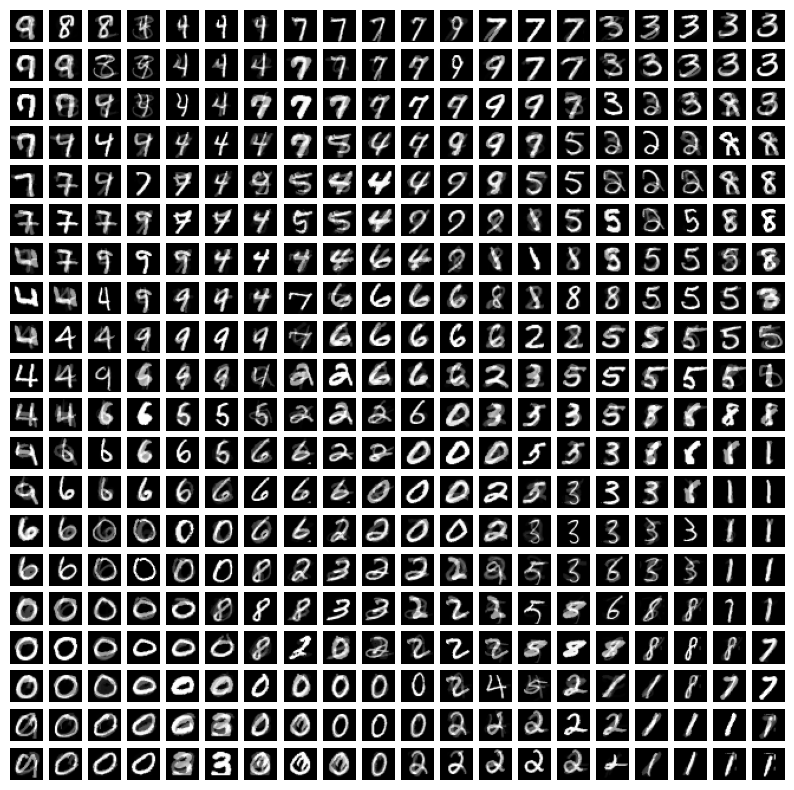

In [28]:
# Name: Aman S Dhole
# PRN: 2141351246051
# Branch: IT
# Semester/Year: 7th/4th
# Practical No: 5
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Load MNIST data (digits 0-9)
mnist = fetch_openml('mnist_784')
X = mnist.data / 255.0  # Normalize the input data
X = np.array(X)

# Define the SOFM class
class SOFM:
    def __init__(self, input_dim, map_dim, learning_rate, radius, num_iterations):
        self.input_dim = input_dim  # Dimensionality of input (784 for MNIST)
        self.map_dim = map_dim  # Dimensions of the map (e.g., 20x20)
        self.learning_rate = learning_rate  # Initial learning rate
        self.radius = radius  # Initial radius for the neighborhood function
        self.num_iterations = num_iterations

        # Initialize weight vectors randomly
        self.weights = np.random.rand(map_dim[0], map_dim[1], input_dim)

        # Calculate time constants for learning rate and radius decay
        self.time_constant_lr = num_iterations / np.log(self.learning_rate)
        self.time_constant_radius = num_iterations / np.log(self.radius)

    def get_bmu(self, sample):
        """Find the best matching unit (BMU) for a given sample."""
        bmu_idx = np.argmin(np.linalg.norm(self.weights - sample, axis=-1))
        return np.unravel_index(bmu_idx, self.weights.shape[:2])

    def update_weights(self, sample, bmu, iteration):
        """Update the weights of the BMU and its neighbors."""
        current_lr = self.learning_rate * np.exp(-iteration / self.time_constant_lr)
        current_radius = self.radius * np.exp(-iteration / self.time_constant_radius)

        for i in range(self.map_dim[0]):
            for j in range(self.map_dim[1]):
                distance_to_bmu = np.linalg.norm(np.array([i, j]) - np.array(bmu))
                if distance_to_bmu <= current_radius:
                    influence = np.exp(-(distance_to_bmu ** 2) / (2 * (current_radius ** 2)))
                    self.weights[i, j] += current_lr * influence * (sample - self.weights[i, j])

    def train(self, X):
        """Train the SOFM using the input data."""
        for iteration in range(self.num_iterations):
            sample = X[np.random.randint(0, X.shape[0])]
            bmu = self.get_bmu(sample)
            self.update_weights(sample, bmu, iteration)

# Initialize and train the SOFM
input_dim = 784  # Each MNIST image is 28x28 = 784 pixels
map_dim = (20, 20)  # 20x20 grid of neurons
learning_rate = 0.1
radius = 10
num_iterations = 5000

sofm = SOFM(input_dim, map_dim, learning_rate, radius, num_iterations)
sofm.train(X)

# Visualize the weight map after training
plt.figure(figsize=(10, 10))
for i in range(map_dim[0]):
    for j in range(map_dim[1]):
        plt.subplot(map_dim[0], map_dim[1], i * map_dim[1] + j + 1)
        plt.imshow(sofm.weights[i, j].reshape(28, 28), cmap='gray')
        plt.axis('off')
plt.show()


Membership value for triangular at x = 5 is: 1.0


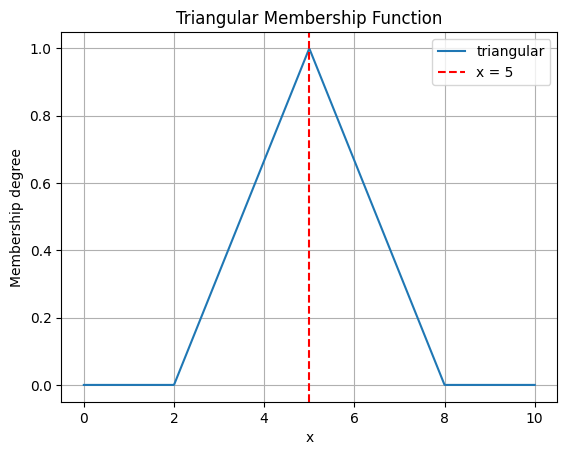

Membership value for trapezoidal at x = 5 is: 1.0


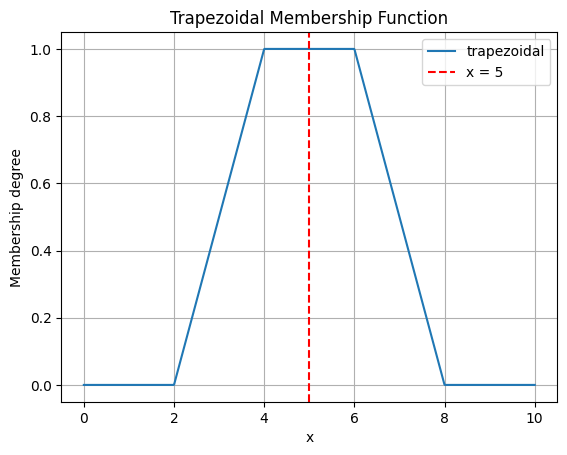

Membership value for gbell at x = 5 is: 1.0


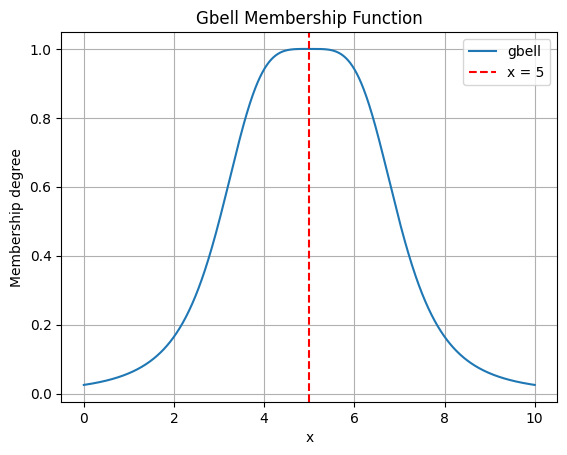

In [2]:
# Name: Aman S Dhole
# PRN: 2141351246051
# Branch: IT
# Semester/Year: 7th/4th
# Practical No: 6
import numpy as np
import matplotlib.pyplot as plt

# Define membership functions
# 1. Triangular Membership Function
def triangular(x, a, b, c):
    return np.maximum(np.minimum((x - a) / (b - a), (c - x) / (c - b)), 0)

# 2. Trapezoidal Membership Function
def trapezoidal(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x - a) / (b - a), 1), (d - x) / (d - c)), 0)

# 3. Generalized Bell (GBell) Membership Function
def gbell(x, a, b, c):
    return 1 / (1 + np.abs((x - c) / a)**(2 * b))

# 4. PI Membership Function
def pi_function(x, a, b):
    if isinstance(x, (int, float)):
        x = np.array([x])
    result = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi <= a:
            result[i] = 0
        elif a < xi <= (a + b) / 2:
            result[i] = 2 * ((xi - a) / (b - a))**2
        elif (a + b) / 2 < xi <= b:
            result[i] = 1 - 2 * ((xi - b) / (b - a))**2
        else:
            result[i] = 0
    return result

# 5. Gamma Membership Function
def gamma_function(x, a, b):
    return np.maximum(np.minimum((x - a) / (b - a), 1), 0)

# 6. Gaussian Membership Function
def gaussian(x, c, sigma):
    return np.exp(-((x - c)**2) / (2 * sigma**2))

# Function to display membership value and graph
def display_membership_value_and_plot(function_name, x_value):
    x = np.linspace(0, 10, 1000)

    if function_name == 'triangular':
        params = (2, 5, 8)
        y = triangular(x, *params)
        membership_value = triangular(x_value, *params)

    elif function_name == 'trapezoidal':
        params = (2, 4, 6, 8)
        y = trapezoidal(x, *params)
        membership_value = trapezoidal(x_value, *params)

    elif function_name == 'gbell':
        params = (2, 2, 5)
        y = gbell(x, *params)
        membership_value = gbell(x_value, *params)

    elif function_name == 'pi':
        params = (3, 7)
        y = pi_function(x, *params)
        membership_value = pi_function(x_value, *params)

    elif function_name == 'gamma':
        params = (3, 7)
        y = gamma_function(x, *params)
        membership_value = gamma_function(x_value, *params)

    elif function_name == 'gaussian':
        params = (5, 1.5)
        y = gaussian(x, *params)
        membership_value = gaussian(x_value, *params)

    else:
        raise ValueError(f"Unknown function name: {function_name}")

    # Print membership value
    print(f"Membership value for {function_name} at x = {x_value} is: {membership_value}")

    # Plot the membership function
    plt.plot(x, y, label=function_name)
    plt.axvline(x=x_value, color='red', linestyle='--', label=f"x = {x_value}")
    plt.title(f'{function_name.capitalize()} Membership Function')
    plt.xlabel('x')
    plt.ylabel('Membership degree')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example: Calculate and display for different membership functions at x = 5
display_membership_value_and_plot('triangular', 5)
display_membership_value_and_plot('trapezoidal', 5)
display_membership_value_and_plot('gbell', 5)
